# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line
## EXERCISES
### Section 2.4 Motion with Constant Acceleration

page 88

#### 2.18 

• Estimate the distance that your car travels on the entrance ramp
to a freeway as it accelerates from 50 km/h to the freeway speed of
110 km/h. During this motion what is the average acceleration of the car?

In [ ]:
# Pass a single comma-separated string to unpack cleanly into 3 symbols
v0, v, dt = sp.symbols(r"v_0, v, \Delta_t", real=True, positive=True)

# Equations for constant acceleration
a_avg = (v - v0) / dt
distance = ((v0 + v) / 2) * dt

# Display formatted LaTeX output
display(Math(rf"a = {sp.latex(a_avg)}"))
display(Math(rf"\Delta x = {sp.latex(distance)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- Using AstroPy for vars with units ---
# Given parameters
v0 = 50.0 * (u.km / u.h)
v = 110.0 * (u.km / u.h)

dt = 5.00 * u.s  # Estimated acceleration time

# Calculations
a_avg = (v - v0) / dt
distance = ((v + v0) / 2) * dt

print(f"Average Acceleration: {a_avg.to(u.m / u.s**2):.2f}")
print(f"Estimated Ramp Distance: {distance.to(u.m):.1f}")


Average Acceleration: 3.33 m / s2
Estimated Ramp Distance: 111.1 m


#### 2.19 

•• An antelope moving with constant acceleration covers the
distance between two points 70.0 m apart in 6.00 s. Its speed as it passes
the second point is 15.0 m/s. What are 

**(a)** its speed at the first point and

**(b)** its acceleration?

In [4]:
# Define symbolic variables
x_diff, dt, v, v0, a = sp.symbols(r"\Delta{x}, \Delta{t}, v, v_0, a", real=True)

# Define kinematic equations
eq1 = sp.Eq(x_diff, ((v0 + v) / 2) * dt)
eq2 = sp.Eq(v, v0 + a * dt)

# Solve symbolically
sol_v0 = sp.solve(eq1, v0)[0]
sol_a = sp.solve(eq2, a)[0]

# Display equations with LHS
display(Math(rf"v_0 = {sp.latex(sol_v0)}"))
display(Math(rf"a = {sp.latex(sol_a)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
# Problem constants with units
delta_x = 70.0 * u.m
delta_t = 6.00 * u.s
v = 15.0 * (u.m / u.s)

# Calculations
v0 = (2 * delta_x / delta_t) - v
a = (v - v0) / delta_t

# Output results
print(f"(a) Speed at first point: {v0.to(u.m / u.s):.2f}")
print(f"(b) Acceleration: {a.to(u.m / u.s**2):.2f}")

(a) Speed at first point: 8.33 m / s
(b) Acceleration: 1.11 m / s2


#### 2.20

page 88

•• **A Tennis Serve**. In the fastest measured tennis serve,
the ball left the racquet at 73.14 m/s. A served tennis ball is typically
in contact with the racquet for 30.0 ms and starts from rest. Assume
constant acceleration. 

**(a)** What was the ball’s acceleration during this
serve? 

**(b)** How far did the ball travel during the serve?

In [ ]:
# Define symbolic variables
v0, v, t, a, x = sp.symbols("v_0 v t a x", real=True, positive=True)

# 1. Acceleration formula from v = v0 + a*t
eq_vel = sp.Eq(v, v0 + a * t)
accel_expr = sp.solve(eq_vel, a)[0]

# 2. Distance formula from x = v0*t + 1/2*a*t^2
dist_expr = (v0 * t + sp.Rational(1, 2) * accel_expr * t**2).simplify()

# Display derived symbolic formulas
display(Math(rf"\text{{Acceleration formula: }} a = {sp.latex(accel_expr)}"))
display(Math(rf"\text{{Displacement formula: }} x = {sp.latex(dist_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Given parameters with Astropy units
v0 = 0.0 * (u.m / u.s)
v = 73.14 * (u.m / u.s)
t = 30.0 * u.ms

# (a) Calculate acceleration: a = (v - v0) / t
acceleration = (v - v0) / t.to(u.s)

# (b) Calculate distance: x = 0.5 * (v0 + v) * t
distance = 0.5 * (v0 + v) * t.to(u.s)

# Print results with formatting matching significant figures
print(
    f"Part (a) Acceleration: {acceleration.value:.2e} {acceleration.unit} ({acceleration.value:.1f} {acceleration.unit})"
)
print(f"Part (b) Distance:     {distance.value:.2f} {distance.unit}")

Part (a) Acceleration: 2.44e+03 m / s2 (2438.0 m / s2)
Part (b) Distance:     1.10 m


#### 2.21

page 88

• **A Fast Pitch**. The fastest measured pitched baseball left the
pitcher’s hand at a speed of 45.0 m/s. If the pitcher was in contact with
the ball over a distance of 1.50 m and produced constant acceleration,

(**a)** what acceleration did he give the ball, and 

**(b)** how much time did it
take him to pitch it?

In [ ]:
# Define symbolic variables
v0, v, x_diff, a, t = sp.symbols("v_0 v x a t", real=True, positive=True)

# 1. Acceleration formula from v^2 = v0^2 + 2*a*x_diff
eq_vel_sq = sp.Eq(v**2, v0**2 + 2 * a * x_diff)
accel_expr = sp.solve(eq_vel_sq, a)[0]

# 2. Time formula from x_diff = ((v0 + v) / 2) * t
eq_dist = sp.Eq(x_diff, ((v0 + v) / 2) * t)
time_expr = sp.solve(eq_dist, t)[0]

# Display general symbolic formulas
display(Math(rf"\text{{Acceleration formula: }} a = {sp.latex(accel_expr)}"))
display(Math(rf"\text{{Time formula: }} t = {sp.latex(time_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Given parameters with Astropy units
v0 = 0.0 * (u.m / u.s)
v = 45.0 * (u.m / u.s)
dx = 1.50 * u.m

# (a) Calculate acceleration: a = (v^2 - v0^2) / (2 * dx)
acceleration = (v**2 - v0**2) / (2 * dx)

# (b) Calculate time: t = 2 * dx/ (v0 + v)
time = (2 * dx) / (v0 + v)

# Print results with formatting matching significant figures
print(f"Part (a) Acceleration: {acceleration.value:.1f} {acceleration.unit}")
print(
    f"Part (b) Time:         {time.value:.4f} {time.unit} ({time.to(u.ms).value:.1f} ms)"
)

Part (a) Acceleration: 675.0 m / s2
Part (b) Time:         0.0667 s (66.7 ms)


#### 2.23 

•• **BIO Automobile Airbags**. 

The human body can survive an
acceleration trauma incident (sudden stop) if the magnitude of the acceleration
is less than 250 m/s2. If you are in an automobile accident
with an initial speed of 105 km/h and are stopped by an airbag that inflates
from the dashboard, over what minimum distance must the airbag
stop you for you to survive the crash?

In [ ]:
# Define symbolic variables
v0, v, a_max, x_min = sp.symbols("v_0 v a_max x_min", real=True, positive=True)

# Kinematic relation: v^2 = v0^2 - 2 * a_max * x_min (where v = 0)
eq = sp.Eq(0, v0**2 - 2 * a_max * x_min)

# Solve for minimum distance
x_min_expr = sp.solve(eq, x_min)[0]

# Display symbolic formulas
display(
    Math(
        rf"\text{{Minimum distance formula: }} x_{{\text{{min}}}} = {sp.latex(x_min_expr)}"
    )
)

<IPython.core.display.Math object>

In [ ]:
# Given parameters with units
v0 = 105.0 * (u.km / u.hour)
v = 0.0 * (u.m / u.s)
a_max = 250.0 * (u.m / (u.s**2))

# Convert initial speed to m/s
v0_ms = v0.to(u.m / u.s)

# Calculate minimum distance: x_min = v0^2 / (2 * a_max)
x_min = (v0_ms**2) / (2 * a_max)

# Print result formatted to 3 significant figures
print(f"Initial Speed: {v0_ms:.3f}")
print(
    f"Minimum Stopping Distance: {x_min.value:.2f} {x_min.unit} ({x_min.to(u.cm).value:.1f} cm)"
)

Initial Speed: 29.167 m / s
Minimum Stopping Distance: 1.70 m (170.1 cm)


#### 2.24 

• **Entering the Freeway**. A car sits on an entrance ramp to a
freeway, waiting for a break in the traffic. Then the driver accelerates
with constant acceleration along the ramp and onto the freeway. The car
starts from rest, moves in a straight line, and has a speed of 20 m/s when
it reaches the end of the 120-m-long ramp. 

**(a)** What is the acceleration
of the car? 

**(b)** How much time does it take the car to travel the length of
the ramp? 

**(c)** The traffic on the freeway is moving at a constant speed
of 20 m/s. What distance does the traffic travel while the car is moving
the length of the ramp?

In [ ]:
# Define symbolic variables
v0, v, x_ramp, a, t, v_traffic, d_traffic = sp.symbols(
    "v_0 v x_{ramp} a t v_{traffic} d_{traffic}", real=True, positive=True
)

# (a) Acceleration formula from v^2 = v0^2 + 2*a*x_ramp
eq_accel = sp.Eq(v**2, v0**2 + 2 * a * x_ramp)
accel_expr = sp.solve(eq_accel, a)[0]

# (b) Time formula from x_ramp = ((v0 + v) / 2) * t
eq_time = sp.Eq(x_ramp, ((v0 + v) / 2) * t)
time_expr = sp.solve(eq_time, t)[0]

# (c) Distance traveled by traffic: d_traffic = v_traffic * t
dist_traffic_expr = v_traffic * time_expr

# Display general formulas
display(Math(rf"\text{{Acceleration: }} a = {sp.latex(accel_expr)}"))
display(Math(rf"\text{{Time on ramp: }} t = {sp.latex(time_expr)}"))
display(Math(rf"\text{{Traffic distance: }} d={sp.latex(dist_traffic_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [51]:
# Given parameters with units
v0 = 0.0 * (u.m / u.s)
v = 20.0 * (u.m / u.s)
x_ramp = 120.0 * u.m
v_traffic = 20.0 * (u.m / u.s)

# (a) Calculate acceleration: a = (v^2 - v0^2) / (2 * x_ramp)
acceleration = (v**2 - v0**2) / (2 * x_ramp)

# (b) Calculate time: t = 2 * x_ramp / (v0 + v)
time_ramp = (2 * x_ramp) / (v0 + v)

# (c) Calculate traffic distance: d_traffic = v_traffic * time_ramp
dist_traffic = v_traffic * time_ramp

# Print results
print(f"Part (a) Acceleration:     {acceleration.value:.3f} {acceleration.unit}")
print(f"Part (b) Ramp Time:        {time_ramp.value:.1f} {time_ramp.unit}")
print(f"Part (c) Traffic Distance: {dist_traffic.value:.1f} {dist_traffic.unit}")

Part (a) Acceleration:     1.667 m / s2
Part (b) Ramp Time:        12.0 s
Part (c) Traffic Distance: 240.0 m


#### 2.25 

• **BIO Airbag Injuries**. During an auto accident, the vehicle’s
airbags deploy and slow down the passengers more gently than if they
had hit the windshield or steering wheel. According to safety standards,
airbags produce a maximum acceleration of 60g that lasts for only
36 ms (or less). How far (in meters) does a person travel in coming to a
complete stop in 36 ms at a constant acceleration of 60g?

In [ ]:
# Define symbolic variables
g, a_mag, t, v0, v, x = sp.symbols("g a_{mag} t v_0 v x", real=True, positive=True)

# Define acceleration in terms of g
a = -a_mag

# Equation 1: Final velocity v = v0 + a*t = 0 -> solve for v0
eq_v = sp.Eq(0, v0 + a * t)
v0_expr = sp.solve(eq_v, v0)[0]

# Equation 2: Displacement x = v0*t + (1/2)*a*t^2
x_expr = (v0_expr * t + sp.Rational(1, 2) * a * t**2).simplify()

# Display general formulas
display(Math(rf"\text{{Initial velocity: }} v_0 = {sp.latex(v0_expr)}"))
display(Math(rf"\text{{Stopping distance: }} x = {sp.latex(x_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
# Given parameters with units
g_accel = const.g0  # Standard gravity (9.80665 m/s^2)
a_mag = 60 * g_accel
t = 36 * u.ms

# Convert duration to seconds
t_sec = t.to(u.s)

# Initial velocity required to stop in time t
v0 = a_mag * t_sec

# Stopping distance: x = 1/2 * a * t^2
x_stopping = 0.5 * a_mag * (t_sec**2)

# Print formatted results
print(f"Deceleration:       {a_mag.to(u.m / (u.s**2)):.2f}")
print(f"Initial Velocity:   {v0.to(u.m / u.s):.3f} ({v0.to(u.km / u.hour):.2f})")
print(f"Stopping Distance:  {x_stopping.to(u.m):.3f} ({x_stopping.to(u.cm):.1f})")

Deceleration:       588.40 m / s2
Initial Velocity:   21.182 m / s (76.26 km / h)
Stopping Distance:  0.381 m (38.1 cm)


#### 2.26 

page 88

<img src="..//pics/Fig_E2_26.png" width=600> 

•• A cat walks in a straight line, which we shall call the x-axis,
with the positive direction to the right. As an observant physicist, you
make measurements of this cat’s motion and construct a graph of the
feline’s velocity as a function of time (Fig. E2.26). 

**(a)** Find the cat’s
velocity at t = 4.0 s and at t = 7.0 s. 

**(b)** What is the cat’s acceleration
at t = 3.0 s? At t = 6.0 s ? At t = 7.0 s ? 

**(c)** What distance does the cat
move during the first 4.5 s? From t = 0 to t = 7.0 s ? 

**(d)** Assuming that
the cat started at the origin, sketch clear graphs of the cat’s acceleration
and position as functions of time.

In [5]:
# Define symbols
t, x0, v0, a = sp.symbols("t x_0 v_0 a", real=True)

# Given linear velocity profile: v_x(t) = 8 - (4/3)*t
v_x = 8 - sp.Rational(4, 3) * t

# Acceleration: derivative of velocity
a_x = sp.diff(v_x, t)

# Position: integral of velocity with x(0) = 0
x_t = sp.integrate(v_x, (t, 0, t))

# Distance
d_45 = v0 * t_1 + 0.5 * a_x * (t_1**2)
dist_45 = sp.integrate(v_x, (t, 0, sp.Rational(9, 2)))
dist_7 = sp.integrate(v_x, (t, 0, 6)) + sp.integrate(-v_x, (t, 6, 7))

display(
    Math(rf"\text{{Acceleration formula: }} a_x(t) = {sp.latex(a_x)}\text{{ cm/s}}^2")
)
display(Math(rf"\text{{Position formula: }} x(t) = {sp.latex(x_t)}\text{{ cm}}"))
display(
    Math(
        rf"v_x(4.0\text{{ s}}) = {sp.latex(v_4)}\text{{ cm/s}} = {float(v_4):.2f}\text{{ cm/s}}"
    )
)
display(
    Math(
        rf"v_x(7.0\text{{ s}}) = {sp.latex(v_7)}\text{{ cm/s}} = {float(v_7):.2f}\text{{ cm/s}}"
    )
)
display(
    Math(
        rf"\text{{Distance (0 to 4.5 s): }} {sp.latex(dist_45)}\text{{ cm}} = {float(dist_45):.2f}\text{{ cm}}"
    )
)
display(
    Math(
        rf"\text{{Distance (0 to 7.0 s): }} {sp.latex(dist_7)}\text{{ cm}} = {float(dist_7):.2f}\text{{ cm}}"
    )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# Linear parameters
v0 = 8.0 * (u.cm / u.s)
t_zero = 6.0 * u.s
a_x = -v0 / t_zero  # -1.333 cm/s^2

# (a) Velocities
v_4 = v0 + a_x * (4.0 * u.s)
v_7 = v0 + a_x * (7.0 * u.s)

# (c) Distances
t_1 = 4.5 * u.s
d_45 = v0 * t_1 + 0.5 * a_x * (t_1**2)

# Total distance from 0 to 7.0 s (split at turning point t = 6 s)
d_forward = v0 * (6.0 * u.s) + 0.5 * a_x * ((6.0 * u.s) ** 2)
d_backward = abs(0.5 * a_x * ((1.0 * u.s) ** 2))
d_total = d_forward + d_backward

print(f"Part (a) v(4s): {v_4.value:.2f} {v_4.unit}")
print(f"Part (a) v(7s): {v_7.value:.2f} {v_7.unit}")
print(f"Part (b) Acceleration: {a_x.value:.3f} {a_x.unit}")
print(f"Part (c) Distance (0 to 4.5s): {d_45.value:.2f} {d_45.unit}")
print(f"Part (c) Distance (0 to 7.0s): {d_total.value:.2f} {d_total.unit}")

Part (a) v(4s): 2.67 cm / s
Part (a) v(7s): -1.33 cm / s
Part (b) Acceleration: -1.333 cm / s2
Part (c) Distance (0 to 4.5s): 22.50 cm
Part (c) Distance (0 to 7.0s): 24.67 cm


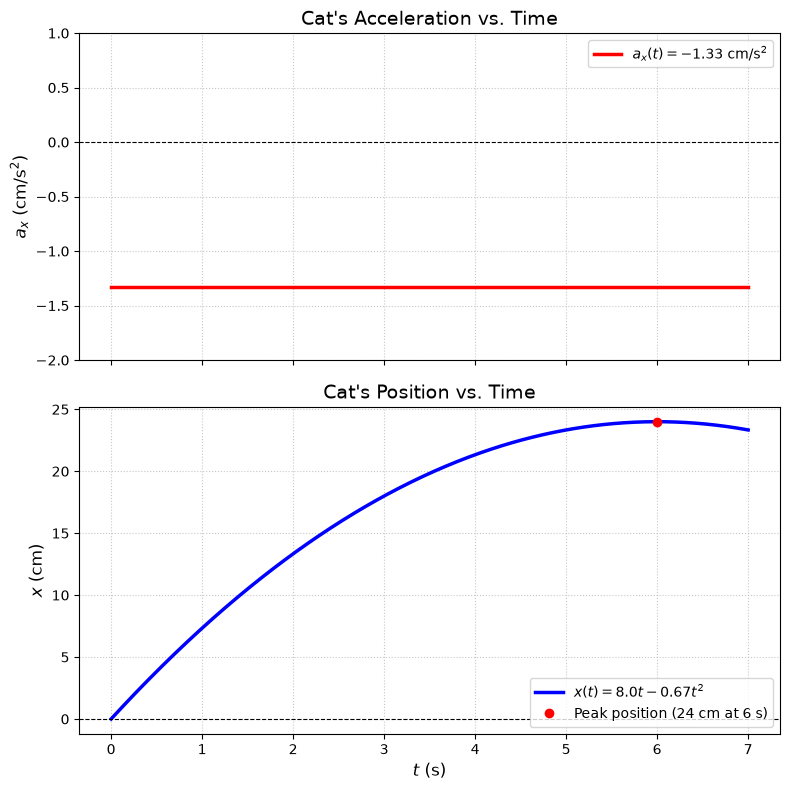

In [7]:
# Time vector
t = np.linspace(0, 7.0, 500)

# Kinematic equations
a_x = np.full_like(t, -4 / 3)
x_t = 8.0 * t - 0.5 * (4 / 3) * (t**2)

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# (d1) Acceleration vs Time
ax1.plot(t, a_x, "r-", linewidth=2.5, label=r"$a_x(t) = -1.33\text{ cm/s}^2$")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel(r"$a_x\text{ (cm/s}^2\text{)}$", fontsize=12)
ax1.set_title("Cat's Acceleration vs. Time", fontsize=14)
ax1.set_ylim(-2.0, 1.0)
ax1.grid(True, linestyle=":", alpha=0.7)
ax1.legend(loc="upper right")

# (d2) Position vs Time
ax2.plot(t, x_t, "b-", linewidth=2.5, label=r"$x(t) = 8.0t - 0.67t^2$")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.plot(6.0, 24.0, "ro", label="Peak position (24 cm at 6 s)")
ax2.set_xlabel(r"$t\text{ (s)}$", fontsize=12)
ax2.set_ylabel(r"$x\text{ (cm)}$", fontsize=12)
ax2.set_title("Cat's Position vs. Time", fontsize=14)
ax2.grid(True, linestyle=":", alpha=0.7)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

#### 2.27 

• **BIO Are We Martians?** It has been suggested, and not facetiously,
that life might have originated on Mars and been carried to the
earth when a meteor hit Mars and blasted pieces of rock (perhaps containing
primitive life) free of the Martian surface. Astronomers know
that many Martian rocks have come to the earth this way. (For instance,
search the Internet for “ALH 84001.”) One objection to this idea is that
microbes would have had to undergo an enormous lethal acceleration
during the impact. Let us investigate how large such an acceleration
might be. To escape Mars, rock fragments would have to reach its escape
velocity of 5.0 km/s, and that would most likely happen over a
distance of about 4.0 m during the meteor impact. 

**(a)** What would be
the acceleration (in m/s2 and g’s) of such a rock fragment, if the acceleration
is constant? 

In [ ]:
# Define symbolic variables
v0, v, x, a, t = sp.symbols("v_0 v x a t", real=True, positive=True)

# 1. Acceleration formula from v^2 = v0^2 + 2*a*x_diff
eq_vel_sq = sp.Eq(v**2, v0**2 + 2 * a * x)
accel_expr = sp.solve(eq_vel_sq, a)[0]

display(Math(rf"\text{{Acceleration formula: }} a = {sp.latex(accel_expr)}"))


<IPython.core.display.Math object>

In [ ]:
# --- Given data, _qty means value for AstroPy ---
v_qty = (5 * (u.km / u.s)).to(u.m / u.s)
v0_qty = 0 * (u.m / u.s)
d_qty = 4 * u.m

# --- Calculate acceleration ---
a_qty = (v_qty**2 - v0_qty**2) / (2 * d_qty)
g_qty = a_qty / const.g0

print(f"Part (a) Acceleration")

print(f"Acceleration: {a_qty:,.1e}")
print(f"Acceleration: {g_qty:,.1e} g")

Part (a) Acceleration
Acceleration: 3.1e+06 m / s2
Acceleration: 3.2e+05 g


**(b)** How long would this acceleration last?

In [20]:
# Define symbolic variables
v0, v, x, a, t = sp.symbols("v_0 v x a t", real=True, positive=True)

# Define kinematic equation
eq = sp.Eq(v, v0 + a * t)

# Solve symbolically
sol_t = sp.solve(eq, t)[0]

# Display equations with LHS
display(Math(rf"t = {sp.latex(sol_t)}"))

<IPython.core.display.Math object>

In [25]:
# --- Calculate time ---
t_qyt = (v_qty - v0_qty) / a_qty
print(f"Time t={t_qyt} equivalent to {t_qyt.to(u.ms)}")

Time t=0.0016 s equivalent to 1.6 ms


**(c)** In
tests, scientists have found that over 40% of Bacillus subtilis bacteria
survived after an acceleration of 450,000g. In light of your answer to
part (a), can we rule out the hypothesis that life might have been blasted
from Mars to the earth?

In [ ]:
a_max_qty = 450_000  # g

a_margin_qty = a_max_qty - g_qty

print(f"Margin acceleration: {a_margin_qty:,.0f} g")
print(
    f"We can not rule out the hypothesis as there is a large margin of acceleration survival."
)

Margin acceleration: 131,339 g
We can not rule out the hypothesis as there is a large margin of acceleration survival.


#### 2.29 

page 89

<img src="..//pics/Fig_E2_29.png" width=400> 

•• The graph in Fig. E2.29
shows the velocity of a motorcycle
police officer plotted as a function
of time. 

**(a)** Find the instantaneous
acceleration at t = 3 s, t = 7 s, and
t = 11 s. 

**(b)** How far does the officer
go in the first 5 s? The first 9 s?
The first 13 s?

In [ ]:
# Key points on the graph
v0_qty = 20.0 * (u.m / u.s)
v1_qty = 45.0 * (u.m / u.s)
v2_qty = 0.0 * (u.m / u.s)

t0_qty = 0.0 * u.s
t1_qty = 5.0 * u.s
t2_qty = 9.0 * u.s
t3_qty = 13.0 * u.s

# --- Part (a): Accelerations ---
a_3s_qty = (v0_qty - v0_qty) / (t1_qty - t0_qty)
a_7s_qty = (v1_qty - v0_qty) / (t2_qty - t1_qty)
a_11s_qty = (v2_qty - v1_qty) / (t3_qty - t2_qty)

# --- Part (b): Distances ---
d_5s_qty = v0_qty * (t1_qty - t0_qty)
d_9s_qty = d_5s_qty + (1 / 2) * (v0_qty + v1_qty) * (t2_qty - t1_qty)
d_13s_qty = d_9s_qty + (1 / 2) * (v1_qty + v2_qty) * (t3_qty - t2_qty)

# Print results
print(f"Part (a) Acceleration at 3s:     {a_3s_qty:.2f}")
print(f"Part (a) Acceleration at 7s:     {a_7s_qty:.2f}")
print(f"Part (a) Acceleration at 11s:  {a_11s_qty:.2f}")

print(f"Part (b) Distance in 5s:         {d_5s_qty:.2f}")
print(f"Part (b) Distance in 9s:         {d_9s_qty:.2f}")
print(f"Part (b) Distance in 13s:        {d_13s_qty:.2f}")


Part (a) Acceleration at 3s:     0.00 m / s2
Part (a) Acceleration at 7s:     6.25 m / s2
Part (a) Acceleration at 11s:  -11.25 m / s2
Part (b) Distance in 5s:         100.00 m
Part (b) Distance in 9s:         230.00 m
Part (b) Distance in 13s:        320.00 m


2.30 

•• A small block has constant
acceleration as it slides down
a frictionless incline. The block is
released from rest at the top of the
incline, and its speed after it has
traveled 6.80 m to the bottom of the incline is 3.80 m/s. What is the
speed of the block when it is 3.40 m from the top of the incline?

In [71]:
# Define symbolic variables
v0, v, x0, x, a, t = sp.symbols("v_0 v x0 x a t", real=True, positive=True)

# 1. Acceleration formula from v^2 = v0^2 + 2*a*x
eq_vel_sq = sp.Eq(v**2, v0**2 + 2 * a * x)
accel_expr = sp.solve(eq_vel_sq, a)[0]
vel_expr = sp.solve(eq_vel_sq, v)[0]

display(Math(rf"\text{{Acceleration formula: }} a = {sp.latex(accel_expr)}"))
display(Math(rf"\text{{Velocity formula: }} v = {sp.latex(vel_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- Given data ---
x0_qty = 0 * u.m
v0_qty = 0 * (u.m / u.s)

x2_qty = 6.80 * u.m
v2_qty = 3.80 * (u.m / u.s)

x1_qty = 3.40 * u.m

# --- 1. Derive callable from SymPy ---
calc_a = sp.lambdify((v, v0, x, x0), accel_expr)
calc_v = sp.lambdify((a, x, v0), vel_expr)

# calculation
a_qty = calc_a(v2_qty, v0_qty, x2_qty, x0_qty)
v_qty = calc_v(a_qty, x1_qty, v0_qty)

print(f"calculated acceleration: {a_qty:.2f}")
print(f"calculated velocity at x1: {v1_qty:.2f}")


calculated acceleration: 1.06 m / s2
calculated velocity at x1: 2.69 m / s


2.31 

•• **(a)** If a flea can jump straight up to a height of 0.440 m,
what is its initial speed as it leaves the ground?

**(b)** How long is it in the air?

In [ ]:
# --- 1. SymPy Symbolic Derivation ---
a, h, v, g_sym, t = sp.symbols("a h v g t", positive=True)

# Formula for v0 from v^2 = v0^2 - 2gh (with v=0 at top)
v0_expr = sp.sqrt(2 * g_sym * h)

# Formula for total time in air: t = 2 * v0 / g
t_expr = 2 * v0_expr / g_sym

calc_v0 = sp.lambdify((g_sym, h), v0_expr)
calc_t = sp.lambdify((g_sym, h), t_expr)

# --- 2. Numerical Values ---
h_qty = 0.440 * u.m
g_qty = const.g0

# --- 3. Calculations ---
v0_qty = calc_v0(g_qty, h_qty)
t_qty = calc_t(g_qty, h_qty).to(u.s)

print(f"Part (a) Initial speed: {v0_qty:.2f}")
print(f"Part (b) Time in air:   {t_qty:.2f}")

Part (a) Initial speed: 2.94 m / s
Part (b) Time in air:   0.60 s


#### 2.32 

•• A small rock is thrown vertically upward with a speed of
22.0 m/s from the edge of the roof of a 30.0-m-tall building. The rock
doesn’t hit the building on its way back down and lands on the street
below. Ignore air resistance. 

**(a)** What is the speed of the rock just before
it hits the street? 

**(b)** How much time elapses from when the rock is
thrown until it hits the street?

In [ ]:
# --- SymPy Symbols (_sym suffix) ---
v0_sym, y0_sym, y_sym, g_sym, t_sym = sp.symbols(
    "v_0 y_0 y g t", real=True, positive=True
)

# 1. Formula for impact velocity squared: v^2 = v0^2 - 2*g*(y - y0)
v_sq_expr = v0_sym**2 + 2 * (-g_sym) * (y_sym - y0_sym)
v_expr = -sp.sqrt(v_sq_expr)  # negative root because rock moves downward
speed_expr = sp.Abs(v_expr)

# 2. Formula for elapsed time: t = (v - v0) / (-g)
t_expr = (v_expr - v0_sym) / (-g_sym)
t_simplified = sp.simplify(t_expr)

display(Math(rf"\text{{Impact speed: }} |v| = {sp.latex(speed_expr)}"))
display(Math(rf"\text{{Elapsed time: }} t = {sp.latex(t_simplified)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- 1. Derive callables from SymPy ---
v0_s, y0_s, g_s = sp.symbols("v_0 y_0 g", positive=True)

v_sq = v0_s**2 + 2 * g_s * y0_s
v_func = sp.lambdify((v0_s, y0_s, g_s), sp.sqrt(v_sq))
t_func = sp.lambdify((v0_s, y0_s, g_s), (sp.sqrt(v_sq) + v0_s) / g_s)

# --- 2. Astropy Quantities (_qty suffix) ---
v0_qty = 22.0 * (u.m / u.s)
y0_qty = 30.0 * u.m
g_qty = 9.80 * (u.m / u.s**2)  # magnitude of g

# --- 3. Calculations ---
speed_qty = v_func(v0_qty, y0_qty, g_qty)
t_qty = t_func(v0_qty, y0_qty, g_qty)

print(f"Part (a) Impact speed: {speed_qty:.2f}")
print(f"Part (b) Elapsed time: {t_qty:.2f}")

Part (a) Impact speed: 32.74 m / s
Part (b) Elapsed time: 5.59 s
